In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

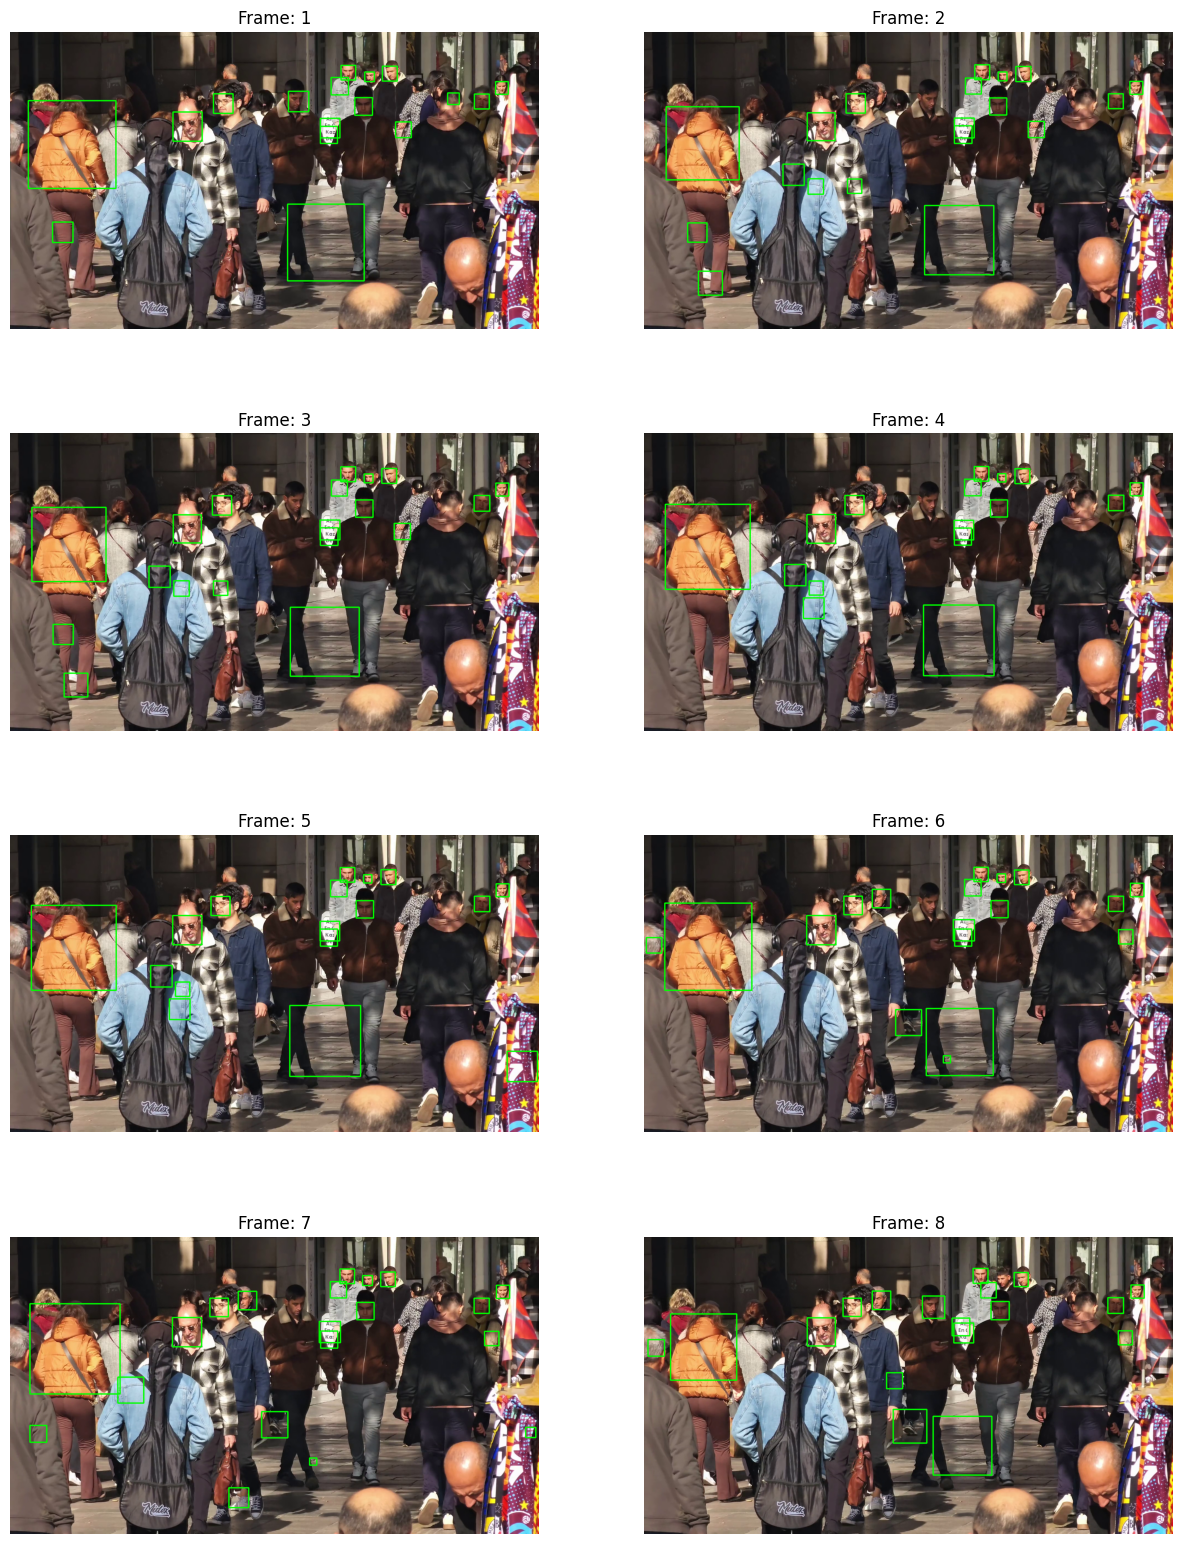

In [25]:
video_path = "/kaggle/input/datasets/nazaninashrafi/face-detection/14737067_1920_1080_60fps.mp4"
cap = cv.VideoCapture(video_path)


face_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_frontalface_default.xml"
)

if face_cascade.empty():
    raise IOError("Failed to load")

output_frames = []

while len(output_frames) < 8:
    ret, frame = cap.read()
    if not ret:
        break

    gray_frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray_frame)

    for(x,y,w,h) in faces:
        cv.rectangle(
            frame,
            (x,y),
            (x+w, y+h),
            (0,255,0),
            4
        )

    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)

    output_frames.append(rgb_frame)

cap.release()

plt.figure(figsize=(15,20))
for i,img  in enumerate(output_frames):
    plt.subplot(4,2,i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Frame: {i + 1}")

plt.show()